In [4]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset
n_rows = 500

data = {
    'Order_ID': [f'ORD-{1000 + i}' for i in range(n_rows)],
    'Order_Date': pd.date_range(start='2025-01-01', periods=n_rows).astype(str),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Books', None], size=n_rows, p=[0.3, 0.3, 0.2, 0.15, 0.05]),
    'Price': np.random.uniform(10, 500, size=n_rows).round(2),
    'Quantity': np.random.choice([1, 2, 3, 4, 5, 100], size=n_rows, p=[0.5, 0.25, 0.15, 0.05, 0.04, 0.01]), # 100 is an outlier
    'Customer_Rating': np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0, np.nan], size=n_rows, p=[0.05, 0.1, 0.2, 0.35, 0.2, 0.1]),
    'Payment_Method': np.random.choice(['Credit Card', 'PayPal', 'UPI', 'Cash on Delivery'], size=n_rows)
}

df_raw = pd.DataFrame(data)

# Inject some intentional dirty data
df_raw.loc[10:12, :] = df_raw.loc[8:10, :].values # Duplicates
df_raw.loc[15:20, 'Price'] = np.nan               # Missing prices

df_raw.to_csv('ecommerce_orders.csv', index=False)
print("Sample dataset 'ecommerce_orders.csv' generated!")

Sample dataset 'ecommerce_orders.csv' generated!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('ecommerce_orders.csv')

# Initial inspection
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Shape ---
(500, 7)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         500 non-null    str    
 1   Order_Date       500 non-null    str    
 2   Category         471 non-null    str    
 3   Price            494 non-null    float64
 4   Quantity         500 non-null    int64  
 5   Customer_Rating  457 non-null    float64
 6   Payment_Method   500 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 27.5 KB
None

--- Missing Values ---
Order_ID            0
Order_Date          0
Category           29
Price               6
Quantity            0
Customer_Rating    43
Payment_Method      0
dtype: int64

--- Summary Statistics ---
            Price    Quantity  Customer_Rating
count  494.000000  500.000000       457.000000
mean   246.424777    3.092000         3.619256
std    139.640181   10.7

In [9]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 3. Handle missing values
# Drop rows where critical info (Category or Price) is missing
df = df.dropna(subset=['Category', 'Price'])

# Fill missing ratings with the median rating
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].median())

# 4. Feature Engineering: Calculate Total Revenue per line item
df['Total_Sales'] = df['Price'] * df['Quantity']

# 5. Handle Outliers in Quantity (e.g., quantities over 20 are likely data entry errors)
df = df[df['Quantity'] <= 20]

print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (458, 8)


,Order_ID,Order_Date,Category,Price,Quantity,Customer_Rating,Payment_Method,Total_Sales
0,ORD-1000,2025-01-01,Clothing,352.10,1,4.0,Cash on Delivery,352.10
2,ORD-1002,2025-01-03,Home & Kitchen,161.67,3,1.0,UPI,485.01
3,ORD-1003,2025-01-04,Clothing,408.76,2,3.0,UPI,817.52
4,ORD-1004,2025-01-05,Electronics,345.52,3,4.0,Cash on Delivery,1036.56
5,ORD-1005,2025-01-06,Electronics,89.68,2,4.0,PayPal,179.36


In [10]:
# Aggregate Sales by Category
category_summary = df.groupby('Category').agg(
    Total_Revenue=('Total_Sales', 'sum'),
    Average_Order_Value=('Total_Sales', 'mean'),
    Total_Orders=('Order_ID', 'count'),
    Avg_Rating=('Customer_Rating', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

print("--- Category Performance ---")
print(category_summary)

# Sales trend over time (Resampled by Month)
df_time = df.set_index('Order_Date').resample('ME')['Total_Sales'].sum().reset_index()
print("\n--- Monthly Revenue ---")
print(df_time)

--- Category Performance ---
         Category  Total_Revenue  Average_Order_Value  Total_Orders  \
2     Electronics       70031.30           466.875333           150   
1        Clothing       62045.77           459.598296           135   
3  Home & Kitchen       44523.20           445.232000           100   
0           Books       34255.75           469.256849            73   

   Avg_Rating  
2    3.653333  
1    3.718519  
3    3.580000  
0    3.657534  

--- Monthly Revenue ---
   Order_Date  Total_Sales
0  2025-01-31     15665.05
1  2025-02-28     12963.18
2  2025-03-31     13413.10
3  2025-04-30     10050.92
4  2025-05-31     12889.92
5  2025-06-30     16087.92
6  2025-07-31     13539.93
7  2025-08-31     16020.90
8  2025-09-30     10534.72
9  2025-10-31     13232.00
10 2025-11-30     11351.81
11 2025-12-31     13497.85
12 2026-01-31     10436.49
13 2026-02-28     10148.42
14 2026-03-31     15786.34
15 2026-04-30     11105.67
16 2026-05-31      4131.80


/tmp/ipykernel_10917/3564529197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


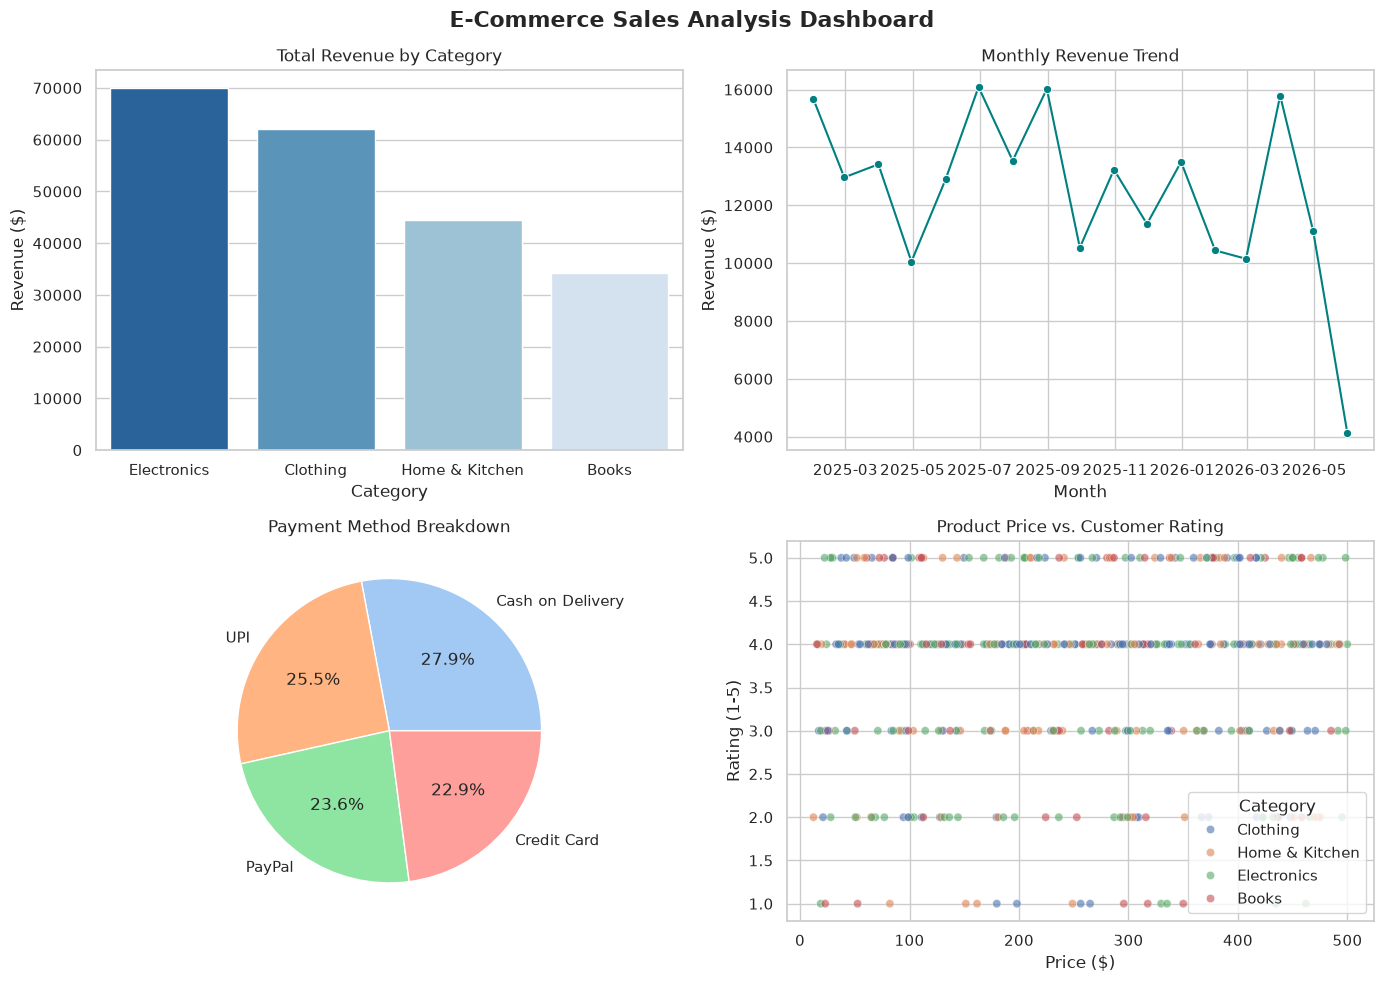

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Sales Analysis Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Total Revenue by Category
sns.barplot(
    data=category_summary, 
    x='Category', 
    y='Total_Revenue', 
    palette='Blues_r', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Total Revenue by Category')
axes[0, 0].set_ylabel('Revenue ($)')

# Chart 2: Monthly Sales Trend
sns.lineplot(
    data=df_time, 
    x='Order_Date', 
    y='Total_Sales', 
    marker='o', 
    color='teal', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Monthly Revenue Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue ($)')

# Chart 3: Payment Method Distribution
df['Payment_Method'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Payment Method Breakdown')
axes[1, 0].set_ylabel('')

# Chart 4: Price vs. Rating Scatter Plot
sns.scatterplot(
    data=df, 
    x='Price', 
    y='Customer_Rating', 
    hue='Category', 
    alpha=0.6, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Product Price vs. Customer Rating')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].set_ylabel('Rating (1-5)')

plt.tight_layout()
plt.show()